In [2]:
# ── 0. Imports & Load Data ───────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# Load the raw data (same as Step 1)
train = pd.read_csv(r"C:\Users\deept\Downloads\train.csv")
test  = pd.read_csv(r"C:\Users\deept\Downloads\test.csv")

print("Train shape:", train.shape)
print("Test  shape:", test.shape)

Train shape: (59598, 24)
Test  shape: (14900, 24)


In [3]:
# ============================================================
# EMPLOYEE ATTRITION — STEP 2: Cleaning + Feature Engineering
# ============================================================

from sklearn.preprocessing import LabelEncoder

# ── 1. Drop useless column ───────────────────────────────────
# Employee ID is just an identifier — no predictive signal
train.drop(columns=["Employee ID"], inplace=True)
test.drop(columns=["Employee ID"],  inplace=True)

print("Train shape after dropping ID:", train.shape)

Train shape after dropping ID: (59598, 23)


In [4]:
# ── 2. Encode target variable ────────────────────────────────
# Models need numbers, not strings
# Left = 1 (the positive class we care about), Stayed = 0
train["Attrition"] = (train["Attrition"] == "Left").astype(int)

print("Target value counts:")
print(train["Attrition"].value_counts())
print(f"\nAttrition rate: {train['Attrition'].mean()*100:.1f}%")

Target value counts:
Attrition
0    31260
1    28338
Name: count, dtype: int64

Attrition rate: 47.5%


In [5]:
# ── 3. Identify ordinal vs nominal columns ───────────────────
# Ordinal = categories that have a natural order  → map to integers
# Nominal = categories with no order             → one-hot encode

ordinal_mappings = {
    "Work-Life Balance":       {"Poor": 1, "Fair": 2, "Good": 3, "Excellent": 4},
    "Job Satisfaction":        {"Low": 1,  "Medium": 2, "High": 3, "Very High": 4},
    "Performance Rating":      {"Low": 1,  "Below Average": 2, "Average": 3,
                                "High": 4, "Very High": 5},
    "Education Level":         {"High School": 1, "Associate Degree": 2,
                                "Bachelor's Degree": 3, "Master's Degree": 4,
                                "PhD": 5},
    "Job Level":               {"Entry": 1, "Mid": 2, "Senior": 3,
                                "Manager": 4, "Director": 5},
    "Company Size":            {"Small": 1, "Medium": 2, "Large": 3},
    "Company Reputation":      {"Poor": 1, "Fair": 2, "Good": 3, "Excellent": 4},
    "Employee Recognition":    {"Low": 1,  "Medium": 2, "High": 3, "Very High": 4},
}

binary_mappings = {
    "Gender":                  {"Male": 0, "Female": 1},
    "Overtime":                {"No": 0, "Yes": 1},
    "Remote Work":             {"No": 0, "Yes": 1},
    "Leadership Opportunities":{"No": 0, "Yes": 1},
    "Innovation Opportunities":{"No": 0, "Yes": 1},
}

nominal_cols = ["Job Role", "Marital Status"]  # no natural order → one-hot

# Apply ordinal mappings to both train and test
for col, mapping in ordinal_mappings.items():
    train[col] = train[col].map(mapping)
    test[col]  = test[col].map(mapping)

# Apply binary mappings
for col, mapping in binary_mappings.items():
    train[col] = train[col].map(mapping)
    test[col]  = test[col].map(mapping)

# One-hot encode nominal columns
train = pd.get_dummies(train, columns=nominal_cols, drop_first=True)
test  = pd.get_dummies(test,  columns=nominal_cols, drop_first=True)

# Align columns — test might be missing a dummy column
train, test = train.align(test, join="left", axis=1, fill_value=0)

print("After encoding — Train shape:", train.shape)
print("Columns:", train.columns.tolist())

After encoding — Train shape: (59598, 27)
Columns: ['Age', 'Gender', 'Years at Company', 'Monthly Income', 'Work-Life Balance', 'Job Satisfaction', 'Performance Rating', 'Number of Promotions', 'Overtime', 'Distance from Home', 'Education Level', 'Number of Dependents', 'Job Level', 'Company Size', 'Company Tenure', 'Remote Work', 'Leadership Opportunities', 'Innovation Opportunities', 'Company Reputation', 'Employee Recognition', 'Attrition', 'Job Role_Finance', 'Job Role_Healthcare', 'Job Role_Media', 'Job Role_Technology', 'Marital Status_Married', 'Marital Status_Single']


In [6]:
# ── 4. Check for any remaining nulls ─────────────────────────
print("Nulls in train:", train.isnull().sum().sum())
print("Nulls in test: ", test.isnull().sum().sum())

Nulls in train: 29846
Nulls in test:  7506


In [9]:
# ── 5. FEATURE ENGINEERING — 3 new meaningful features ───────
# These capture business logic that raw columns miss

# Feature 1: Income per Year of Experience
# Rationale: underpaid employees relative to tenure are more likely to leave
train["Income_per_Tenure_Year"] = train["Monthly Income"] / (train["Years at Company"] + 1)
test["Income_per_Tenure_Year"]  = test["Monthly Income"]  / (test["Years at Company"]  + 1)

# Feature 2: Promotion Deprivation
# Rationale: long tenure with few promotions signals career stagnation → attrition risk
train["Promotion_Deprivation"] = train["Years at Company"] - (train["Number of Promotions"] * 3)
test["Promotion_Deprivation"]  = test["Years at Company"]  - (test["Number of Promotions"]  * 3)

# Feature 3: Wellbeing Score (composite)
# Rationale: combines job satisfaction, work-life balance, and recognition into one signal
train["Wellbeing_Score"] = (
    train["Job Satisfaction"] +
    train["Work-Life Balance"] +
    train["Employee Recognition"]
)
test["Wellbeing_Score"] = (
    test["Job Satisfaction"] +
    test["Work-Life Balance"] +
    test["Employee Recognition"]
)

# Feature 4: Stress Score (overtime + distance from home, normalised)
# Rationale: overtime and long commutes are classic burnout drivers
train["Stress_Score"] = train["Overtime"] + (train["Distance from Home"] / train["Distance from Home"].max())
test["Stress_Score"]  = test["Overtime"]  + (test["Distance from Home"]  / test["Distance from Home"].max())

print("New features created: Income_per_Tenure_Year, Promotion_Deprivation, Wellbeing_Score, Stress_Score")
print("Final Train shape:", train.shape)

New features created: Income_per_Tenure_Year, Promotion_Deprivation, Wellbeing_Score, Stress_Score
Final Train shape: (59598, 31)


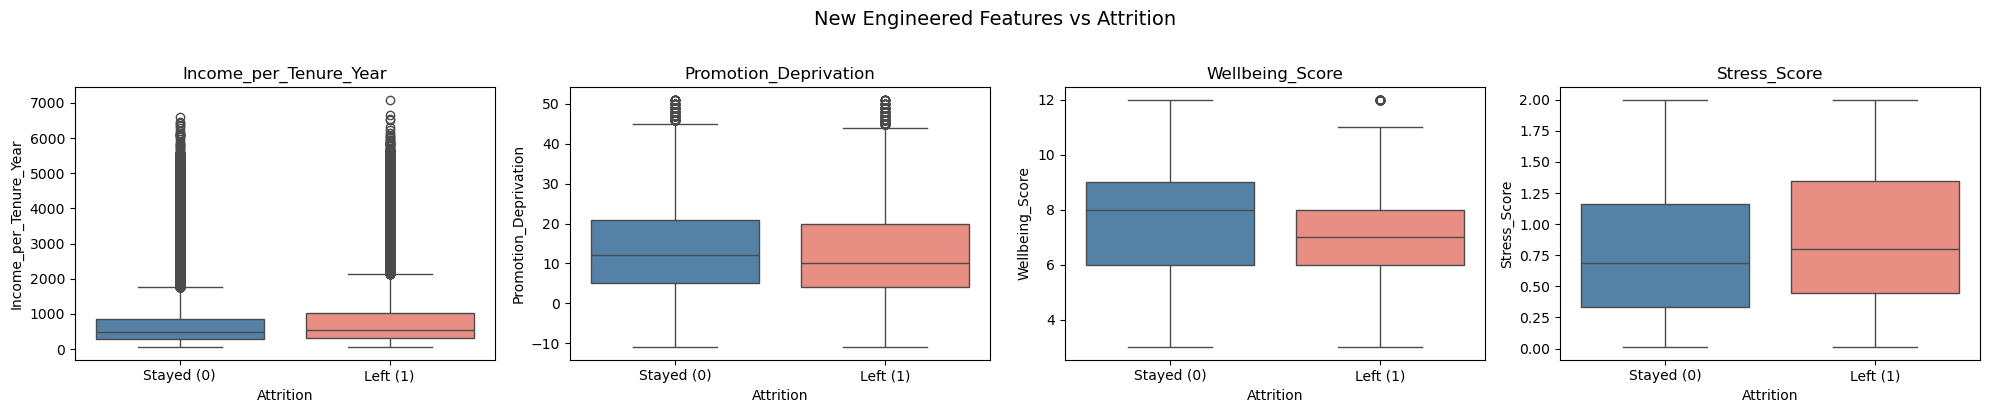

In [10]:
# ── 6. Validate new features visually ───────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
new_features = ["Income_per_Tenure_Year", "Promotion_Deprivation",
                "Wellbeing_Score", "Stress_Score"]

for i, feat in enumerate(new_features):
    sns.boxplot(data=train, x="Attrition", y=feat, ax=axes[i],
                palette=["steelblue", "salmon"])   # ← list instead of dict
    axes[i].set_title(feat)
    axes[i].set_xticklabels(["Stayed (0)", "Left (1)"])

plt.suptitle("New Engineered Features vs Attrition", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("engineered_features.png", dpi=150)
plt.show()

In [11]:
# ── 7. Separate features and target ─────────────────────────
X = train.drop(columns=["Attrition"])
y = train["Attrition"]

print(f"Features (X): {X.shape}")
print(f"Target  (y): {y.shape}  |  Attrition rate: {y.mean()*100:.1f}%")
print("\n✅ Step 2 complete — data is clean and features are engineered.")
print("NEXT → Step 3: Model Training & Evaluation")

Features (X): (59598, 30)
Target  (y): (59598,)  |  Attrition rate: 47.5%

✅ Step 2 complete — data is clean and features are engineered.
NEXT → Step 3: Model Training & Evaluation
